Loading model and tokenizer...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Extracting attention weights...
Plotting heatmaps...
Saved: ../outputs/attention_maps\layer_0_head_0.png


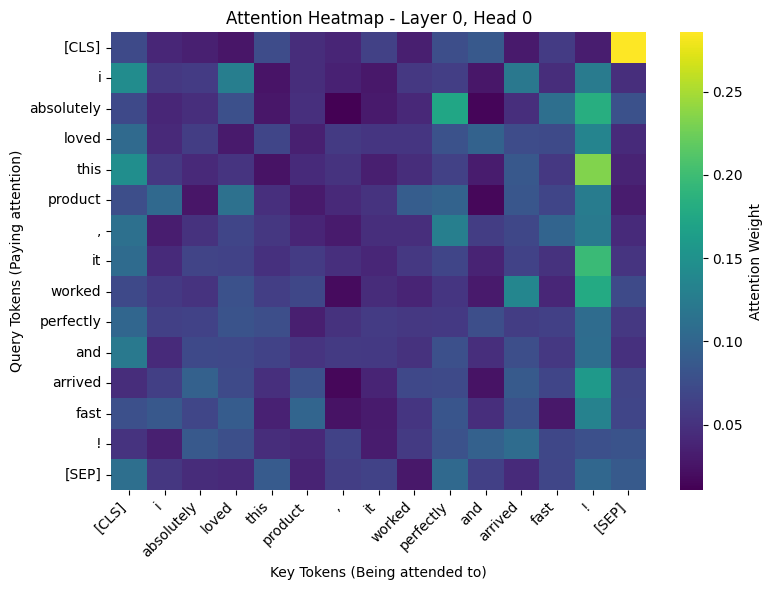

Saved: ../outputs/attention_maps\layer_11_head_4.png


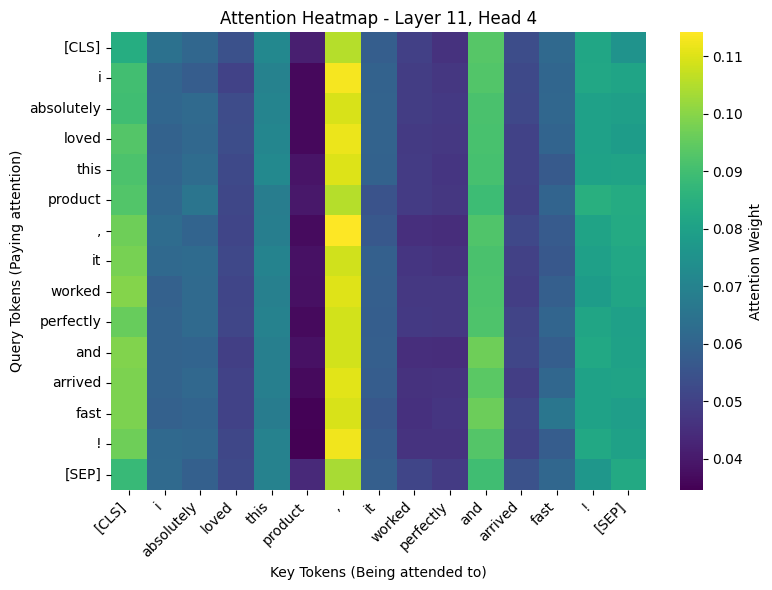

In [ ]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_path = "../outputs/saved_models" 
print("Loading model and tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path, 
    output_attentions=True 
)

sample_text = "I absolutely loved this product, it worked perfectly and arrived fast!"
inputs = tokenizer(sample_text, return_tensors="pt")

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Extracting attention weights...")
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

output_dir = "../outputs/attention_maps"
os.makedirs(output_dir, exist_ok=True)

def plot_attention_heatmap(tokens, attention_matrix, layer_num, head_num):
    plt.figure(figsize=(8, 6))

    attn_data = attention_matrix[0, head_num].numpy()
    
    sns.heatmap(
        attn_data, 
        xticklabels=tokens, 
        yticklabels=tokens, 
        cmap="viridis", 
        cbar_kws={'label': 'Attention Weight'}
    )
    
    plt.title(f"Attention Heatmap - Layer {layer_num}, Head {head_num}")
    plt.xlabel("Key Tokens (Being attended to)")
    plt.ylabel("Query Tokens (Paying attention)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    save_path = os.path.join(output_dir, f"layer_{layer_num}_head_{head_num}.png")
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Saved: {save_path}")
    plt.show()

print("Plotting heatmaps...")

plot_attention_heatmap(tokens, attentions[0], layer_num=0, head_num=0)

plot_attention_heatmap(tokens, attentions[11], layer_num=11, head_num=4)